<a href="https://colab.research.google.com/github/EverHernandez01/Teoria_de_se-ales/blob/main/Taller/AudioSDRVisual00a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

Saving audio_8130000Hz_21-23-49_30-09-2024.wav to audio_8130000Hz_21-23-49_30-09-2024.wav


In [11]:
file_name = list(uploaded.keys())[0]
print("Archivo cargado:", file_name)

Archivo cargado: audio_8130000Hz_21-23-49_30-09-2024.wav


Archivo: audio_8130000Hz_21-23-49_30-09-2024.wav
SHA256: d78c7b8ba1556c5365459c8f3483291f5b337b2144e9069205a7e111079a1859
Sample rate [Hz]: 48000
Duración [s]: 30.465


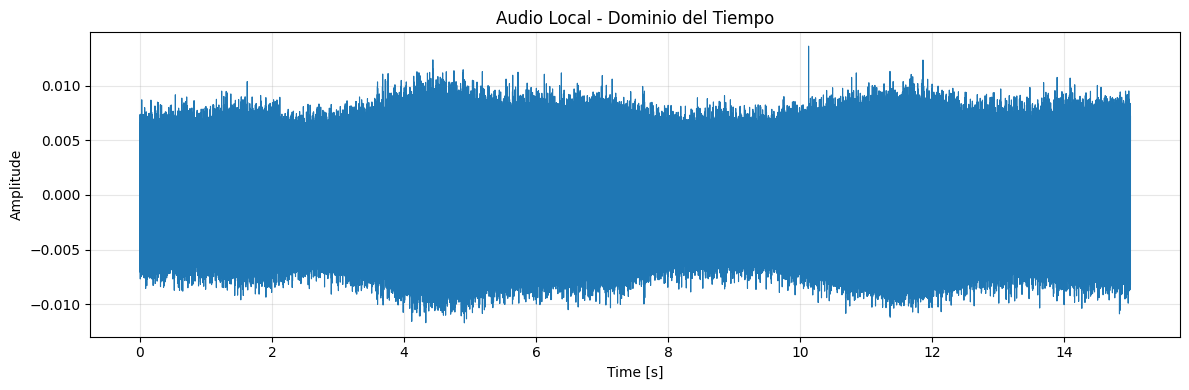

In [12]:
"""
End-to-end: Local WAV file -> robust load -> plot waveform in time domain.

Requirements:
  pip install numpy torch matplotlib soundfile scipy
  + ffmpeg available on PATH (optional but recommended)

Works with:
  - Google Colab (after uploading file)
  - Jupyter Notebook
  - Local Python
"""

from __future__ import annotations

import hashlib
import os
import subprocess
import tempfile
from typing import Tuple, Union

import numpy as np
import torch
import matplotlib.pyplot as plt


# =============================================================================
# Utilities
# =============================================================================

def _int_to_float32(x: np.ndarray) -> np.ndarray:
    if not np.issubdtype(x.dtype, np.integer):
        raise TypeError(f"Expected integer PCM array, got dtype={x.dtype}")
    info = np.iinfo(x.dtype)
    scale = float(max(abs(info.min), abs(info.max)))
    if scale == 0.0:
        return x.astype(np.float32)
    return (x.astype(np.float32) / scale).astype(np.float32, copy=False)


def to_mono_float32(x: np.ndarray) -> np.ndarray:
    if x.ndim == 0:
        raise ValueError("Audio array is scalar; expected 1D or 2D audio.")
    if np.issubdtype(x.dtype, np.integer):
        x = _int_to_float32(x)
    else:
        x = x.astype(np.float32, copy=False)

    if x.ndim == 2:
        x = x.mean(axis=1, dtype=np.float32)
    elif x.ndim != 1:
        raise ValueError(f"Unsupported audio shape {x.shape}; expected [T] or [T, C].")

    return x.astype(np.float32, copy=False)


def has_soundfile() -> bool:
    try:
        import soundfile as _  # noqa: F401
        return True
    except Exception:
        return False


def has_ffmpeg() -> bool:
    try:
        return subprocess.call(
            ["ffmpeg", "-version"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        ) == 0
    except Exception:
        return False


# =============================================================================
# Robust WAV loader
# =============================================================================

def load_wav_mono(path: Union[str, os.PathLike]) -> Tuple[torch.Tensor, int]:
    """
    Robust audio loader that returns mono float32 torch tensor.

    Load order:
      1) soundfile
      2) scipy.io.wavfile
      3) ffmpeg fallback
    """
    path = os.fspath(path)
    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    # 1) soundfile
    try:
        import soundfile as sf

        data, sr = sf.read(path, dtype="float32", always_2d=False)
        data = np.asarray(data, dtype=np.float32)
        data = to_mono_float32(data)
        return torch.from_numpy(data).contiguous(), int(sr)
    except Exception:
        pass

    # 2) scipy
    try:
        from scipy.io import wavfile

        sr, data = wavfile.read(path)
        data = to_mono_float32(np.asarray(data))
        return torch.from_numpy(data).contiguous(), int(sr)
    except Exception:
        pass

    # 3) ffmpeg fallback
    if not has_ffmpeg():
        raise RuntimeError(
            "No se pudo decodificar el audio.\n"
            "Instala soundfile o ffmpeg."
        )

    from scipy.io import wavfile

    with tempfile.TemporaryDirectory() as td:
        tmp_wav = os.path.join(td, "converted.wav")

        cmd = [
            "ffmpeg", "-y",
            "-i", path,
            "-ac", "1",
            "-c:a", "pcm_s16le",
            tmp_wav,
        ]
        subprocess.run(cmd, check=True)

        sr, data = wavfile.read(tmp_wav)
        data = to_mono_float32(np.asarray(data))
        return torch.from_numpy(data).contiguous(), int(sr)


# =============================================================================
# Hash utility
# =============================================================================

def sha256_file(path: Union[str, os.PathLike], chunk_bytes: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(os.fspath(path), "rb") as f:
        while True:
            b = f.read(chunk_bytes)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


# =============================================================================
# Plotting (time domain)
# =============================================================================

def plot_waveform_time_domain(
    waveform: torch.Tensor,
    sample_rate: int,
    *,
    max_duration_s: float = 10.0,
    title: str = "Waveform (Time Domain)",
    normalize: bool = False,
):
    if sample_rate <= 0:
        raise ValueError("sample_rate must be > 0")

    x = waveform.reshape(-1).detach().cpu().to(torch.float32)

    n = int(max_duration_s * sample_rate)
    x = x[: max(1, n)]

    if normalize:
        m = torch.max(torch.abs(x)).clamp_min(1e-12)
        x = x / m

    t = torch.arange(x.numel(), dtype=torch.float32) / float(sample_rate)

    plt.figure(figsize=(12, 4))
    plt.plot(t.numpy(), x.numpy(), linewidth=0.8)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN – LOCAL FILE
# =============================================================================

if __name__ == "__main__":

    # 🔴 CAMBIA ESTE NOMBRE POR TU ARCHIVO
    WAV_PATH = "audio_8130000Hz_21-23-49_30-09-2024.wav"

    if not os.path.isfile(WAV_PATH):
        raise FileNotFoundError(f"No se encontró el archivo: {WAV_PATH}")

    x, sr = load_wav_mono(WAV_PATH)
    duration_s = float(x.numel()) / float(sr)

    print("Archivo:", WAV_PATH)
    print("SHA256:", sha256_file(WAV_PATH))
    print("Sample rate [Hz]:", sr)
    print("Duración [s]:", duration_s)

    plot_waveform_time_domain(
        x,
        sr,
        max_duration_s=15.0,
        title="Audio Local - Dominio del Tiempo",
        normalize=False,
    )

Archivo: audio_8130000Hz_21-23-49_30-09-2024.wav
Frecuencia de muestreo [Hz]: 48000
Duración [s]: 30.465


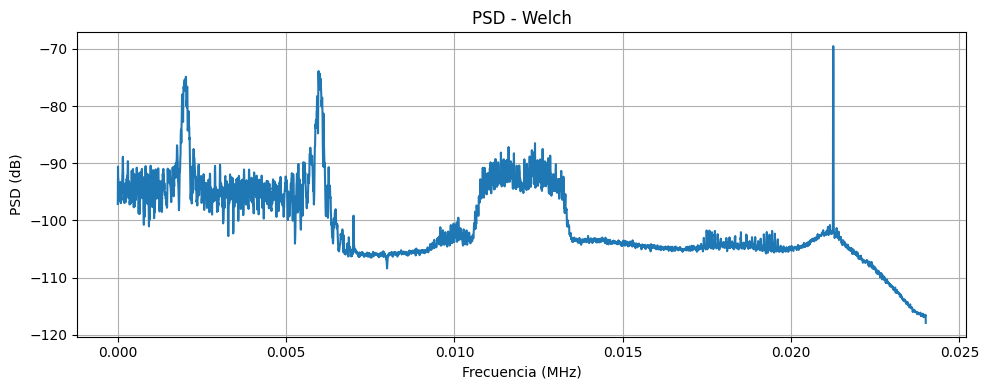

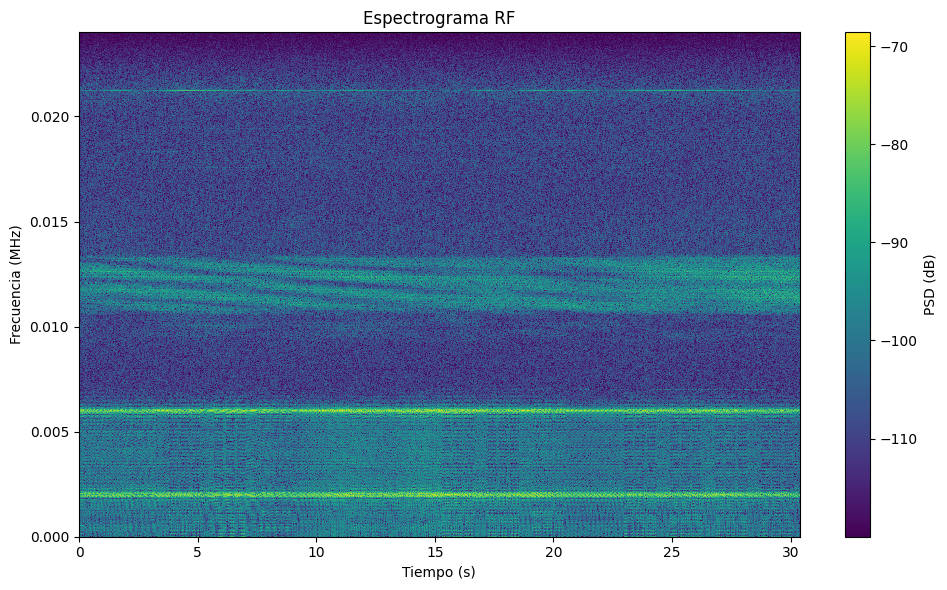

In [14]:
# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.io import wavfile


# ============================================================
# 1) LOAD WAV (MONO)
# ============================================================

def load_wav_mono(path):

    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"No se encontró el archivo:\n{os.path.abspath(path)}\n"
            f"Directorio actual: {os.getcwd()}"
        )

    try:
        import soundfile as sf
        data, sr = sf.read(path, dtype="float32")
    except Exception:
        sr, data = wavfile.read(path)

    data = np.asarray(data)

    # Convert int → float
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float32)
        data /= np.max(np.abs(data))

    # Convert stereo → mono
    if data.ndim == 2:
        data = data.mean(axis=1)

    return torch.from_numpy(data.astype(np.float32)), int(sr)


# ============================================================
# 2) WELCH PSD
# ============================================================

def welch_psd_db(
    waveform,
    sr,
    nperseg=8192,
    noverlap=4096,
    n_fft=None
):

    x = waveform.numpy()

    freqs, Pxx = welch(
        x,
        fs=sr,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=n_fft,
        scaling="density"
    )

    psd_db = 10 * np.log10(Pxx + 1e-12)

    return torch.from_numpy(freqs), torch.from_numpy(psd_db)


# ============================================================
# 3) WELCH SPECTROGRAM
# ============================================================

def welch_spectrogram_db(
    waveform,
    sr,
    frame_len=4096,
    hop_len=1024,
    n_fft=None
):

    x = waveform.numpy()
    window = np.hanning(frame_len)

    if n_fft is None:
        n_fft = frame_len

    frames = []
    times = []

    for start in range(0, len(x) - frame_len, hop_len):
        segment = x[start:start + frame_len] * window
        spectrum = np.fft.rfft(segment, n=n_fft)
        psd = (np.abs(spectrum) ** 2) / (sr * np.sum(window ** 2))
        frames.append(psd)
        times.append(start / sr)

    S = np.array(frames)
    freqs = np.fft.rfftfreq(n_fft, 1/sr)

    S_db = 10 * np.log10(S + 1e-12)

    return (
        torch.from_numpy(np.array(times)),
        torch.from_numpy(freqs),
        torch.from_numpy(S_db)
    )


# ============================================================
# =====================   MAIN   =============================
# ============================================================

# --- CAMBIA EL NOMBRE SI ES NECESARIO ---
file_name = "audio_8130000Hz_21-23-49_30-09-2024.wav"

# ============================================================
# 1) Cargar audio
# ============================================================

waveform, sr = load_wav_mono(file_name)

duration_s = float(waveform.numel()) / float(sr)

print("Archivo:", file_name)
print("Frecuencia de muestreo [Hz]:", sr)
print("Duración [s]:", duration_s)


# ============================================================
# 2) PSD usando Welch
# ============================================================

f_psd, psd_db = welch_psd_db(
    waveform,
    sr,
    nperseg=8192,
    noverlap=4096,
    n_fft=8192,
)

plt.figure(figsize=(10,4))
plt.plot(f_psd.numpy()/1e6, psd_db.numpy())
plt.xlabel("Frecuencia (MHz)")
plt.ylabel("PSD (dB)")
plt.title("PSD - Welch")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 3) Espectrograma
# ============================================================

t, f_spec, S_db = welch_spectrogram_db(
    waveform,
    sr,
    frame_len=4096,
    hop_len=1024,
    n_fft=4096,
)

plt.figure(figsize=(10,6))
plt.pcolormesh(
    t.numpy(),
    f_spec.numpy()/1e6,
    S_db.numpy().T,
    shading='auto'
)

plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (MHz)")
plt.title("Espectrograma RF")
plt.colorbar(label="PSD (dB)")
plt.tight_layout()
plt.show()

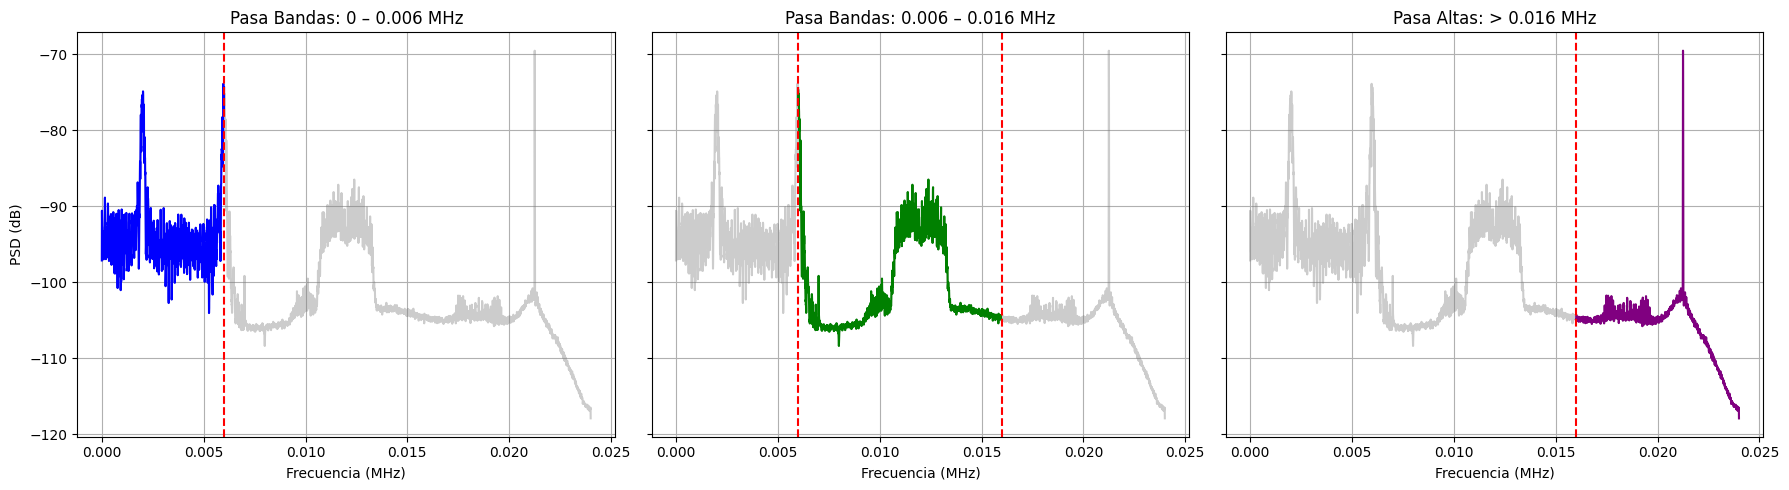

In [16]:
# ============================================================
# PREPARAR DATOS
# ============================================================

f = f_psd.numpy()
psd = psd_db.numpy()

f1 = 0.006e6
f2 = 0.016e6

# Máscaras de banda
mask_pb1 = (f <= f1)
mask_pb2 = (f > f1) & (f <= f2)
mask_hp = (f > f2)


# ============================================================
# FIGURA 3x1
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(18,5), sharey=True)

# ------------------------------------------------------------
# 1) PASA BANDAS 0 – 0.006 MHz
# ------------------------------------------------------------
axs[0].plot(f/1e6, psd, color="gray", alpha=0.4)

axs[0].plot(f[mask_pb1]/1e6, psd[mask_pb1], color="blue")

axs[0].axvline(f1/1e6, color="red", linestyle="--")

axs[0].set_title("Pasa Bandas: 0 – 0.006 MHz")
axs[0].set_xlabel("Frecuencia (MHz)")
axs[0].set_ylabel("PSD (dB)")
axs[0].grid(True)


# ------------------------------------------------------------
# 2) PASA BANDAS 0.006 – 0.016 MHz
# ------------------------------------------------------------
axs[1].plot(f/1e6, psd, color="gray", alpha=0.4)

axs[1].plot(f[mask_pb2]/1e6, psd[mask_pb2], color="green")

axs[1].axvline(f1/1e6, color="red", linestyle="--")
axs[1].axvline(f2/1e6, color="red", linestyle="--")

axs[1].set_title("Pasa Bandas: 0.006 – 0.016 MHz")
axs[1].set_xlabel("Frecuencia (MHz)")
axs[1].grid(True)


# ------------------------------------------------------------
# 3) PASA ALTAS > 0.016 MHz
# ------------------------------------------------------------
axs[2].plot(f/1e6, psd, color="gray", alpha=0.4)

axs[2].plot(f[mask_hp]/1e6, psd[mask_hp], color="purple")

axs[2].axvline(f2/1e6, color="red", linestyle="--")

axs[2].set_title("Pasa Altas: > 0.016 MHz")
axs[2].set_xlabel("Frecuencia (MHz)")
axs[2].grid(True)


plt.tight_layout()
plt.show()

RMSE: 0.0


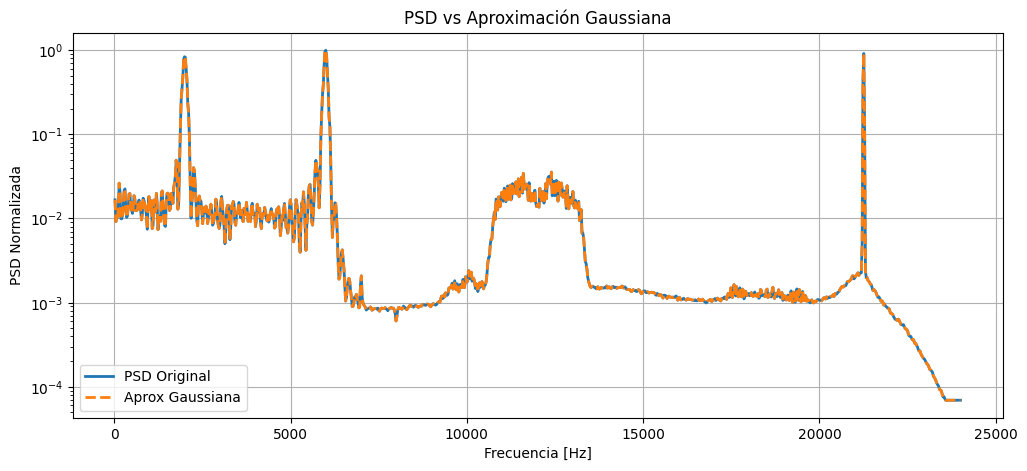

In [34]:
# ============================================================
# APROXIMACION PSD COMO SUMA DE GAUSSIANAS (METODO DENSO)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# convertir PSD a numpy
freq_hz = f_psd.cpu().numpy()
psd_db_np = psd_db.cpu().numpy()

# usar solo frecuencias positivas
mask = freq_hz > 0
freq_hz = freq_hz[mask]
psd_db_np = psd_db_np[mask]


# ------------------------------------------------------------
# convertir PSD a escala lineal
# ------------------------------------------------------------

psd_lin = 10**(psd_db_np/10)

# normalizar PSD
psd_norm = psd_lin / np.max(psd_lin)

# normalizar frecuencia
freq_norm = freq_hz / np.max(freq_hz)


# ------------------------------------------------------------
# PARAMETROS DE LAS GAUSSIANAS
# ------------------------------------------------------------

mu_n = freq_norm.copy()
omega_n = psd_norm.copy()

# calcular ancho gaussiano
spacing = np.diff(mu_n)
min_spacing = np.min(spacing[spacing > 0])

alpha = np.log(len(mu_n)/1e-10)/(min_spacing**2)
alpha_n = np.full_like(mu_n, alpha)


# ------------------------------------------------------------
# RECONSTRUCCION
# ------------------------------------------------------------

delta = freq_norm[None,:] - mu_n[:,None]

basis = np.exp(-alpha_n[:,None]*(delta**2))

psd_fit = (omega_n[:,None]*basis).sum(axis=0)


# ------------------------------------------------------------
# ERROR
# ------------------------------------------------------------

mse = np.mean((psd_fit-psd_norm)**2)
rmse = np.sqrt(mse)

print("RMSE:", rmse)


# ------------------------------------------------------------
# GRAFICA
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.semilogy(
    freq_hz,
    psd_norm,
    label="PSD Original",
    linewidth=2
)

plt.semilogy(
    freq_hz,
    psd_fit,
    "--",
    label="Aprox Gaussiana",
    linewidth=2
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD Normalizada")

plt.title("PSD vs Aproximación Gaussiana")

plt.grid(True)
plt.legend()

plt.show()

Frecuencia original: 48000
Frecuencia MFCC: 16000
Dimensión MFCC: (13, 3045)


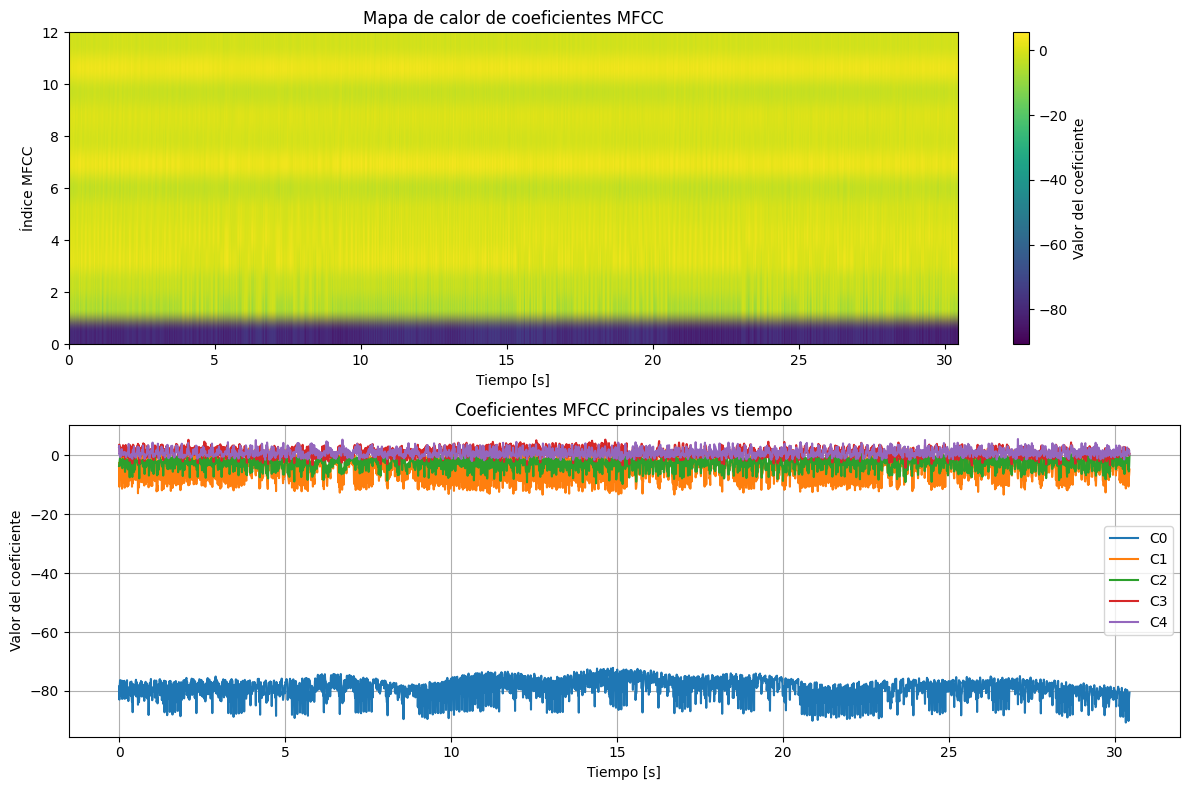

In [41]:
# ============================================================
# MFCC COMPLETO (COMPATIBLE CON TU PIPELINE x, sr)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample_poly
from scipy.fft import dct


# ============================================================
# 1️⃣ CONVERTIR AUDIO A MONO
# ============================================================

def to_mono_float32(samples):

    x = np.asarray(samples)

    if x.ndim == 2:
        x = x.mean(axis=1)

    return x.astype(np.float32)


# ============================================================
# 2️⃣ RESAMPLE A 16 kHz PARA MFCC
# ============================================================

def resample_audio(samples, original_sr, target_sr=16000):

    if original_sr == target_sr:
        return samples, original_sr

    import math

    g = math.gcd(original_sr, target_sr)

    up = target_sr // g
    down = original_sr // g

    y = resample_poly(samples, up, down)

    return y.astype(np.float32), target_sr


# ============================================================
# 3️⃣ BANCO DE FILTROS MEL
# ============================================================

def hz_to_mel(f):
    return 2595 * np.log10(1 + f/700)

def mel_to_hz(m):
    return 700 * (10**(m/2595) - 1)


def mel_filterbank(sr, n_fft, n_mels=40):

    f_min = 0
    f_max = sr/2

    mel_points = np.linspace(
        hz_to_mel(f_min),
        hz_to_mel(f_max),
        n_mels+2
    )

    hz_points = mel_to_hz(mel_points)

    bins = np.floor((n_fft+1)*hz_points/sr).astype(int)

    fb = np.zeros((n_mels, n_fft//2 + 1))

    for m in range(1, n_mels+1):

        f_left = bins[m-1]
        f_center = bins[m]
        f_right = bins[m+1]

        for k in range(f_left, f_center):
            fb[m-1,k] = (k-f_left)/(f_center-f_left)

        for k in range(f_center, f_right):
            fb[m-1,k] = (f_right-k)/(f_right-f_center)

    return fb


# ============================================================
# 4️⃣ CALCULO MFCC
# ============================================================

def compute_mfcc(signal, sr,
                 frame_len=0.025,
                 hop_len=0.010,
                 n_fft=1024,
                 n_mels=40,
                 n_mfcc=13):

    frame_len = int(frame_len*sr)
    hop_len = int(hop_len*sr)

    # framing
    num_frames = 1 + int((len(signal)-frame_len)/hop_len)

    frames = np.zeros((num_frames, frame_len))

    for i in range(num_frames):

        start = i*hop_len
        frames[i] = signal[start:start+frame_len]

    # ventana Hamming
    frames *= np.hamming(frame_len)

    # FFT
    spec = np.fft.rfft(frames, n_fft)

    power = (np.abs(spec)**2)/n_fft

    # mel
    fb = mel_filterbank(sr, n_fft, n_mels)

    mel_energy = power @ fb.T

    mel_log = np.log(mel_energy + 1e-10)

    # DCT
    mfcc = dct(mel_log, type=2, axis=1, norm='ortho')[:,:n_mfcc]

    return mfcc.T


# ============================================================
# 5️⃣ PREPARAR AUDIO (USA TU VARIABLE x, sr)
# ============================================================

audio_samples = x.cpu().numpy()

mono_samples = to_mono_float32(audio_samples)

mfcc_input, mfcc_sr = resample_audio(mono_samples, sr, 16000)

mfcc = compute_mfcc(mfcc_input, mfcc_sr)

time_axis = np.arange(mfcc.shape[1])*0.01


print("Frecuencia original:", sr)
print("Frecuencia MFCC:", mfcc_sr)
print("Dimensión MFCC:", mfcc.shape)


# ============================================================
# 6️⃣ GRAFICAS
# ============================================================

fig, axes = plt.subplots(2,1,figsize=(12,8))


# ------------------------------------------------------------
# MAPA DE CALOR MFCC
# ------------------------------------------------------------

im = axes[0].imshow(
    mfcc,
    aspect='auto',
    origin='lower',
    extent=[0,time_axis[-1],0,mfcc.shape[0]-1],
    cmap='viridis'
)

axes[0].set_title("Mapa de calor de coeficientes MFCC")
axes[0].set_xlabel("Tiempo [s]")
axes[0].set_ylabel("Índice MFCC")

plt.colorbar(im, ax=axes[0], label="Valor del coeficiente")


# ------------------------------------------------------------
# COEFICIENTES MFCC PRINCIPALES
# ------------------------------------------------------------

for i in range(5):

    axes[1].plot(
        time_axis,
        mfcc[i],
        linewidth=1.5,
        label=f"C{i}"
    )

axes[1].set_title("Coeficientes MFCC principales vs tiempo")
axes[1].set_xlabel("Tiempo [s]")
axes[1].set_ylabel("Valor del coeficiente")

axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()